In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('train.csv', index_col = 0)

In [4]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.size

9801

In [7]:
df.shape

(891, 11)

So, we have 891 rows and 11 columns, the ultimate goal - detect who survives - binary classification

Columns - Name, sex, age, sibsp, parch, ticket, fare, cabin, embarked

In [8]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

We have 5 numerical data - survived, pclass, sibsp, parch, fare and 5 categorical data - object

Gotta do smth with ticket - either remove it , it  can;t be encoded and I am very unsure what different ticket may indicate

In [9]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

so, we have zero null values, except in age - 177 null values, cabin - 687, embarked - 2 

We can decide what to do with them - some can be dropped, some for example is almost fully null - feels like okay to drop? but first gott figure out the importance of this column

In [10]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Like here we see that mean age is 30, we can do either this with null age values - fill null values in range of ~30

Based on this describe stats, what we infer:

age: mean = 29.7, median (50%) = 28 -> normal distribution, but anomaly - 177 missing values. Since mean and median close -> no skeweness, mostly symmetric

survived: man = 0.38 -> 38% survived -> most died, std = 0.48 high but okay for binary values, median = 0, most died

pclass: mean = 2.31 -> class 2 and 3 prevalent, median = 3 most were 3rd class, 75 % = 3, most passengers were 3rd class -> passengers motly were poor

sibsp: mean = 0.52, median = 0 -> mostly traveled alone, 75% had 0 or 1 family members, max = 8 unusual, maybe outlier, gotta do smth with it

parch: parents + children abroad -> mostly no parents/chidlren together, mean = 0.38 and 50% = 0, no parents and children traveling together

fare: crazy anomalies - mean = 32 and median = 14 huge difference -> skewed, min = 0 (why 0 maybe crew or data error??) and max = 512 huge difference, while 75% is only 31, std = 49 bigger than mean, extremely high variation

All insights so far


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


Let's see unique values of each column to understand what we will need to decode/encode later or just get to know more


In [12]:
df['Pclass'].unique()

array([3, 1, 2])

In [13]:
# content of unique values
df['Cabin'].unique()

# number of unique values
df['Cabin'].nunique()

147

and etc

# work wih visualizations

In [14]:
# bar plot, histogram, scatter plot, box plot, line plot

Bar plots used to visualize categorical data. For example, we could have used it to compare how many people survived and how many didn't or difference in survival between genders, how different was number of people in every class (1, 2, 3)

In [15]:
women = len(df[(df['Survived'] == 1) & (df['Sex'] == 'female')])

In [16]:
women

233

In [17]:
men = len(df[(df['Survived'] == 1) & (df['Sex'] == 'male')])

In [18]:
men

109

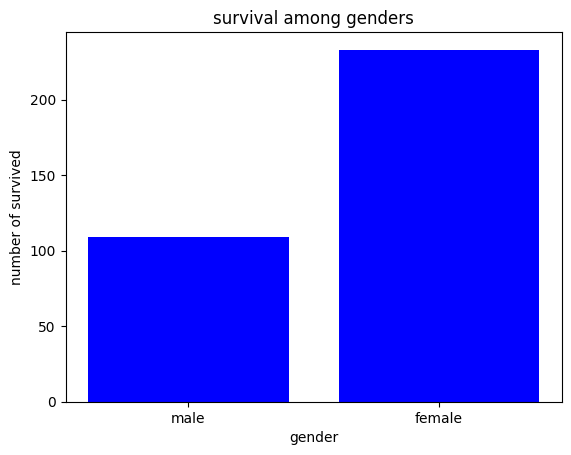

In [19]:
gender = ['male', 'female']
number = [109, 233]

plt.bar(gender, number, color='blue')
plt.title('survival among genders')
plt.xlabel('gender')
plt.ylabel('number of survived')
plt.show()

Histogram for continuous data spread outs (test scoress, heights, temperatures), no gaps in comparison to bar plots that are used for distinct groups. 

I can use it for age or fare, mostly we use graphs to reveal some info or insights, so these should tell us about inequalities, which we noticed by describe are existent in age and fare columns

Histogram help to reveal skeweness (shape of distribution), outliers, then in feature engineering and preprocessing it needs to be addressed - skewed data or smth or maybe use models that okay with this.  


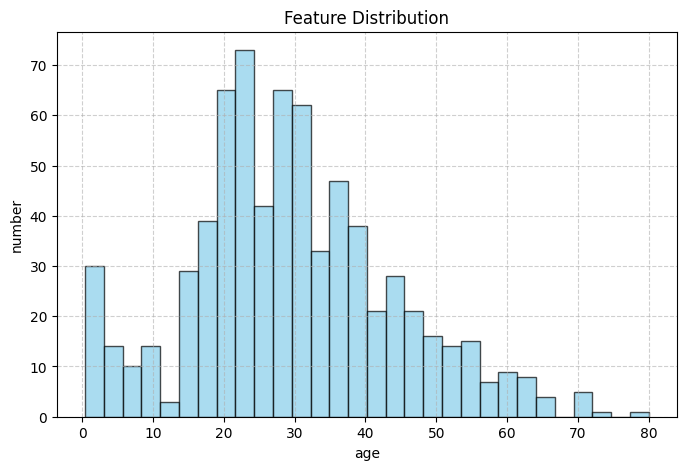

In [20]:
data = df['Age']

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Feature Distribution')
plt.xlabel('age')
plt.ylabel('number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

it is not really symmetric, if it was symmetric =, we would see peak right in the middle, which is not true, perfect number in right and left, more values on the right - right skewed, if it was more values on left - left skewed

more advanced - can add some line over graph that would openly hightlight that

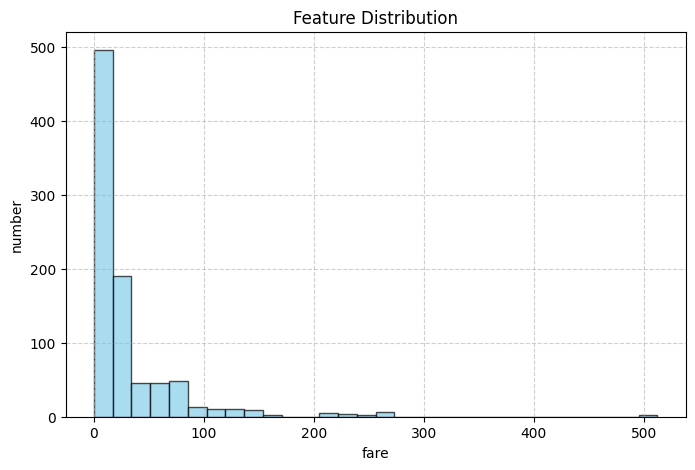

In [21]:
data = df['Fare']

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Feature Distribution')
plt.xlabel('fare')
plt.ylabel('number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## scatterplot

This is used to see correlation, if existent or not is positive there is correlation between x and y and as x increases, y increases, in case of negative if x increases, y decreases

what we could see - as example, maybe rich people survived more frequently than poor people? and lost of other insights we can take, but for now I will only do 1 graph cause I am running out of time


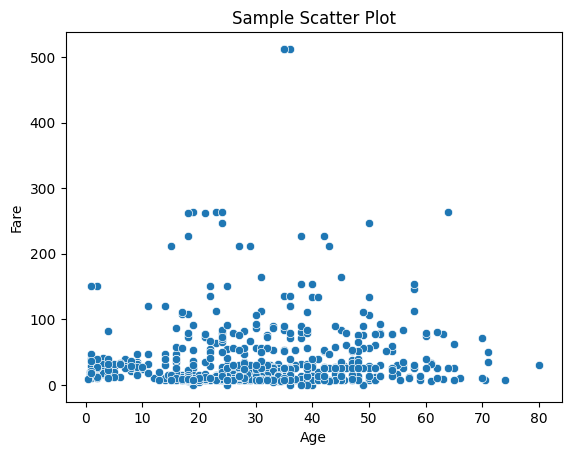

In [22]:
data = df

sns.scatterplot(data=data, x='Age', y='Fare')
plt.title("Sample Scatter Plot")
plt.show()

interesting: the most expensive tickets of 500 were bought by people of age in range 30-40 and what i can also infer is that most children had usual price of tickets, so mostly parents with children weren't rich (?)

## box plot 

reveal important info about outliers, extreme cases, where is mean/median. observing data symmetry, and identifying the spread of data when basic averages (like the mean) are misleading

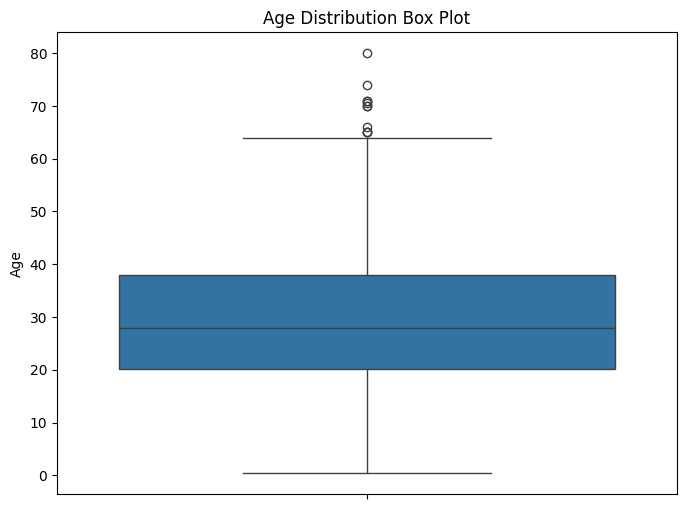

In [23]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title("Age Distribution Box Plot")
plt.ylabel("Age")
plt.show()

## last but not least - line plot

/var/folders/t5/nw7hty0126j_mj5c0pb8dnf40000gn/T/ipykernel_78633/295183831.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = df.groupby(pd.cut(df['Age'].dropna(), bins=10))['Survived'].mean()


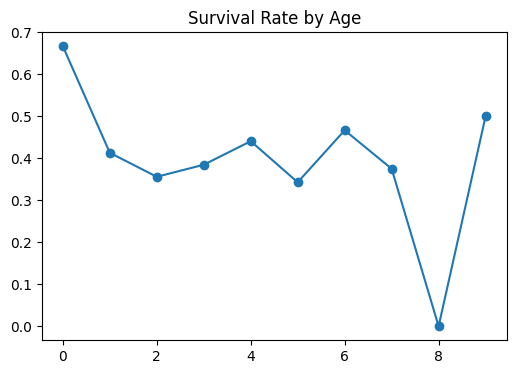

In [24]:
plt.figure(figsize=(6,4))
age_groups = df.groupby(pd.cut(df['Age'].dropna(), bins=10))['Survived'].mean()
plt.plot(range(len(age_groups)), age_groups.values, marker='o')
plt.title('Survival Rate by Age')
plt.show()


In [25]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [28]:
# barplot: survival rate and Pclass
survival_rate = df.groupby('Pclass')['Survived'].mean().sort_values(ascending=False)
survival_rate

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

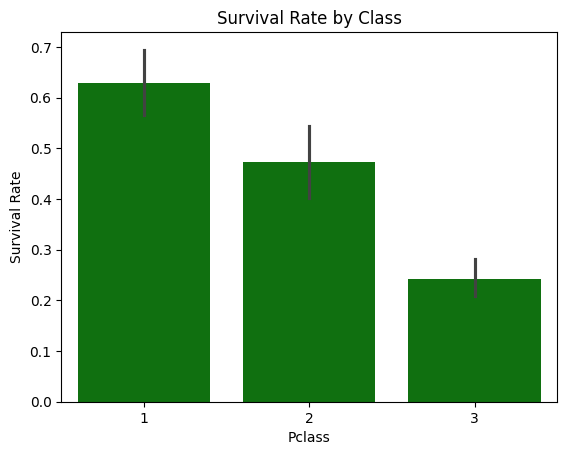

In [31]:
sns.barplot(x='Pclass', y='Survived', data=df, color='green')
plt.title('Survival Rate by Class')
plt.ylabel('Survival Rate')
plt.show()

In [32]:
# barplot: survival rate and port (embarked)
survival_rate = df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False)
survival_rate

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

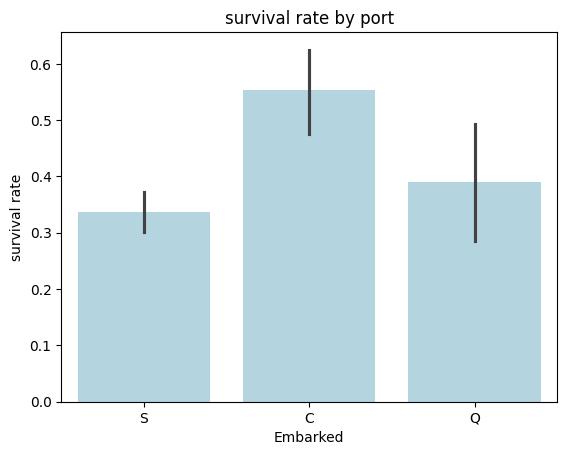

In [33]:
sns.barplot(x='Embarked', y='Survived', data=df, color='lightblue')
plt.title("survival rate by port")
plt.ylabel("survival rate")
plt.show()

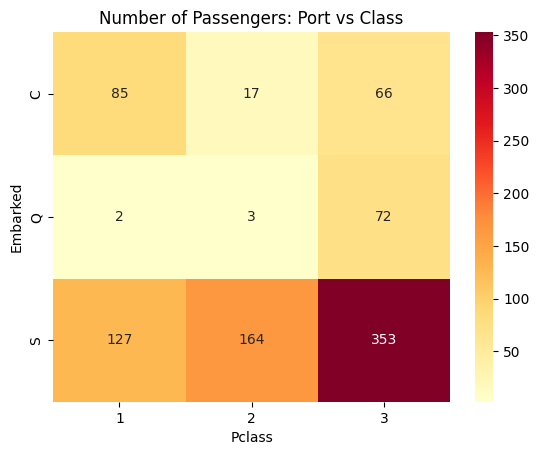

In [34]:
# is there relationship between pclass and embarked?
cross_tab = pd.crosstab(df['Embarked'], df['Pclass'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Number of Passengers: Port vs Class')
plt.show()

In [35]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

I can infer that C despite having least amount of people, most people were from here who survived. 

The reason maybe that in S there was most people who were from 3rd class and survived least. 

So, we can conclude, righer people -> higher chance of survival, poorer people -> lower chance of survival. 


In [36]:
# survival rate and fare
survival_rate = df.groupby('Fare')['Survived'].mean().sort_values(ascending=False)
survival_rate

Fare
512.3292    1.0
57.9792     1.0
13.8583     1.0
13.7917     1.0
13.4167     1.0
           ... 
15.5500     0.0
47.1000     0.0
46.9000     0.0
42.4000     0.0
21.0750     0.0
Name: Survived, Length: 248, dtype: float64

In [37]:
# now lets see if people who had siblings or spouse survived more or not
survival_rate = df.groupby('SibSp')['Survived'].mean().sort_values(ascending=False)
survival_rate

SibSp
1    0.535885
2    0.464286
0    0.345395
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

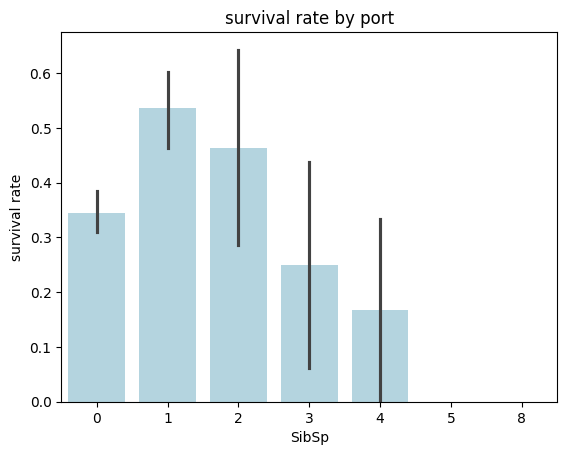

In [38]:
sns.barplot(x='SibSp', y='Survived', data=df, color='lightblue')
plt.title("survival rate by port")
plt.ylabel("survival rate")
plt.show()

In [39]:
# so we can infer mostly survived those who had 1 sibling or a spouse, so 1, 2, then 0

In [40]:
survival_rate = df.groupby('Parch')['Survived'].mean().sort_values(ascending=False)
survival_rate

Parch
3    0.600000
1    0.550847
2    0.500000
0    0.343658
5    0.200000
4    0.000000
6    0.000000
Name: Survived, dtype: float64

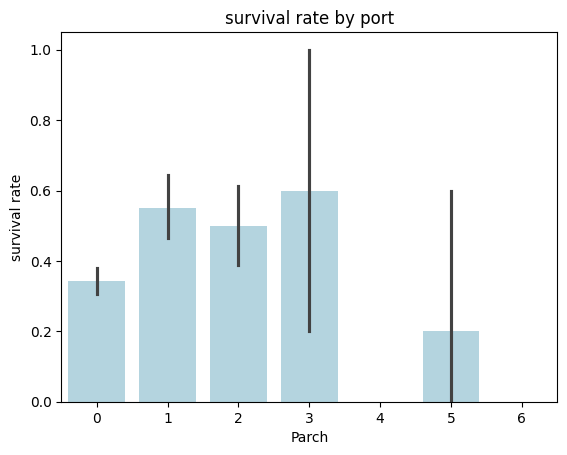

In [41]:
sns.barplot(x='Parch', y='Survived', data=df, color='lightblue')
plt.title("survival rate by port")
plt.ylabel("survival rate")
plt.show()

In [42]:
# even more interesting if people with sibling/spouse survived more across all classes?
sibsp_class_survival = df.groupby(['Pclass', 'SibSp'])['Survived'].mean().unstack()
print(sibsp_class_survival)

SibSp          0         1         2         3         4    5    8
Pclass                                                            
1       0.562044  0.746479  0.800000  0.666667       NaN  NaN  NaN
2       0.416667  0.581818  0.500000  1.000000       NaN  NaN  NaN
3       0.236467  0.325301  0.333333  0.083333  0.166667  0.0  0.0


In [ ]:
# feature engineering ideas :
- age: because mostly age is always binned
- familysize: because differently separately parch and sibsp give patterns, but together, they will be easier for interpreatibility
- title in names
                                                                                                              
# how can i work with feature ticket?

## 3RD DAY - Linear models

I will try on two datasets, first I will use Logistic Regression on the dataset that I almost didn't change and then on dataset that I changed somewhat yesterday. Both these .ipynbs will need to be pushed to github. 

In [43]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [65]:
X = df.iloc[:, [1, 4, 5, 6, 8]]
y = df[['Survived']]
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

In [66]:
X

,Pclass,Age,SibSp,Parch,Fare
PassengerId,,,,,
1,3,22.0,1,0,7.2500
2,1,38.0,1,0,71.2833
3,3,26.0,0,0,7.9250
4,1,35.0,1,0,53.1000
5,3,35.0,0,0,8.0500
...,...,...,...,...,...
887,2,27.0,0,0,13.0000
888,1,19.0,0,0,30.0000
889,3,NaN,1,2,23.4500


In [68]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)

lr = LogisticRegression(max_iter=1000, random_state=0)
lr.fit(X_train_imputed, y_train)

y_pred = lr.predict_proba(X_train_imputed)  
loss = log_loss(y_train, y_pred)

print(loss)

0.5711666312100937


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


I simplified the dataset too much. Deleted lots of columns, this is logistic regression for the first not modified dataset